# Churn Analysis: Decision Trees and Association Rules
Complete analysis including CART, C4.5 decision trees, decision rules, and association rules.

---

# ================================================================
# QUESTION 1: DECISION TREE ANALYSIS
# ================================================================
Generate CART and C4.5 decision trees, normalize data, handle correlations, and analyze rules.

In [1]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree

## Step 1: Data Preparation - Normalization and Correlation Handling

In [3]:
# Load the full churn dataset
file_path = r"C:\Users\prabe\Desktop\BSIT375\churn.xlsx"
df_full = pd.read_excel(file_path)

# Display basic information
print("Dataset shape:", df_full.shape)
print("\nColumn names:")
print(df_full.columns.tolist())
print("\nFirst few rows:")
print(df_full.head())
print("\nData types:")
print(df_full.dtypes)
print("\nMissing values:")
print(df_full.isnull().sum())

Dataset shape: (667, 20)

Column names:
['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

First few rows:
  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   
3    SC             111        415                 No              No   
4    HI              49        510                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5      

### Prepare Data: Normalize Numerical and Handle Correlations

In [4]:
# Separate numerical and categorical columns
numerical_cols = df_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_full.select_dtypes(include=['object']).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

# Check correlation among numerical variables
print("\nCorrelation matrix (numerical variables):")
corr_matrix = df_full[numerical_cols].corr()
print(corr_matrix)

# Identify and remove highly correlated variables (threshold > 0.9)
print("\nIdentifying highly correlated variables (|r| > 0.9):")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
            print(f"{corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

# For decision tree, we'll keep all features but normalize the numerical ones
df_tree = df_full.copy()

# Normalize numerical columns using StandardScaler
if numerical_cols:
    scaler = StandardScaler()
    df_tree[numerical_cols] = scaler.fit_transform(df_tree[numerical_cols])
    print("\nNumerical columns have been normalized (StandardScaler)")

# Encode categorical variables
df_tree_encoded = pd.get_dummies(df_tree, drop_first=True)
print("\nDataset shape after encoding:", df_tree_encoded.shape)

Numerical columns: ['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']
Categorical columns: ['State', 'International plan', 'Voice mail plan']

Correlation matrix (numerical variables):
                        Account length  Area code  Number vmail messages  \
Account length                1.000000  -0.026327              -0.011993   
Area code                    -0.026327   1.000000              -0.006907   
Number vmail messages        -0.011993  -0.006907               1.000000   
Total day minutes             0.017833   0.051507              -0.069172   
Total day calls               0.035703  -0.008972              -0.009952   
Total day charge              0.017839   0.051492              -0.069187   
To

### (a) CART Decision Tree

**CART (Classification and Regression Trees)** uses Gini Index as the splitting criterion.

CART Decision Tree (Gini Index)
Tree Depth: 14
Number of Leaves: 50
Training Accuracy: 1.0000


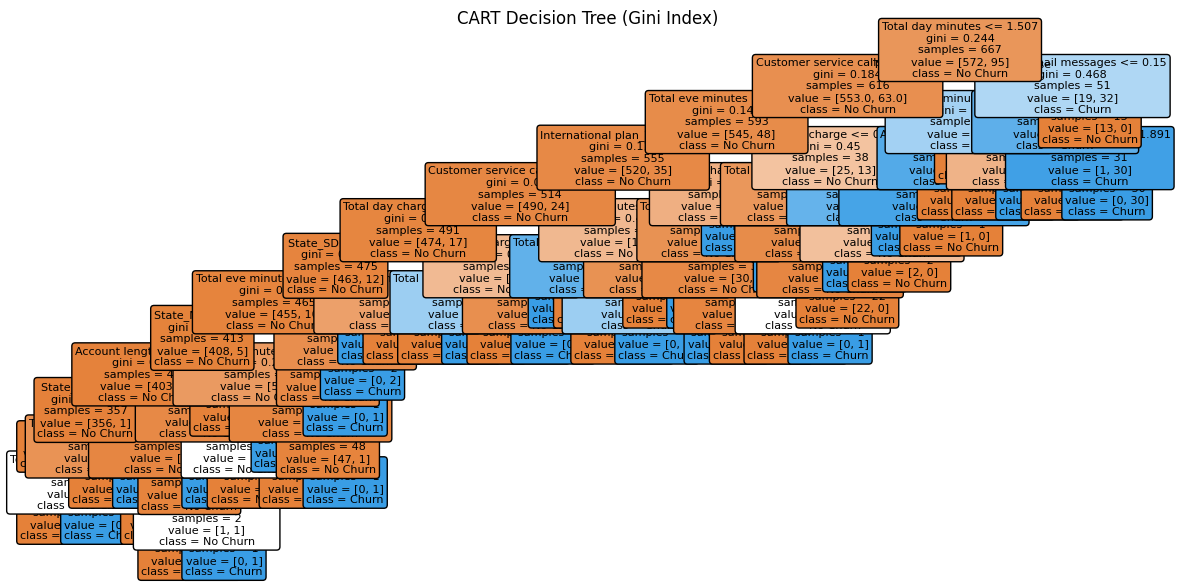


CART Tree Text Representation:
|--- Total day minutes <= 1.51
|   |--- Customer service calls <= 2.20
|   |   |--- Total eve minutes <= 1.45
|   |   |   |--- International plan_Yes <= 0.50
|   |   |   |   |--- Customer service calls <= 1.45
|   |   |   |   |   |--- Total day charge <= 1.19
|   |   |   |   |   |   |--- State_SD <= 0.50
|   |   |   |   |   |   |   |--- Total eve minutes <= 1.01
|   |   |   |   |   |   |   |   |--- State_MD <= 0.50
|   |   |   |   |   |   |   |   |   |--- Account length <= 1.25
|   |   |   |   |   |   |   |   |   |   |--- State_RI <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- class: False
|   |   |   |   |   |   |   |   |   |   |--- State_RI >  0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |   |   |   |   |   |--- Account length >  1.25
|   |   |   |   |   |   |   |   |   |   |--- Total day calls <= 2.01
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 4
|   |   |   

In [5]:
# Prepare data for tree building - find Churn column dynamically
churn_cols = [col for col in df_tree_encoded.columns if 'Churn' in col]
if not churn_cols:
    raise ValueError("No Churn column found in encoded data")
y_col = churn_cols[0]
X = df_tree_encoded.drop(y_col, axis=1)
y = df_tree_encoded[y_col]

# Generate CART Decision Tree (Gini criterion)
cart_tree = DecisionTreeClassifier(criterion='gini', random_state=42)
cart_tree.fit(X, y)

print("CART Decision Tree (Gini Index)")
print(f"Tree Depth: {cart_tree.get_depth()}")
print(f"Number of Leaves: {cart_tree.get_n_leaves()}")
print(f"Training Accuracy: {cart_tree.score(X, y):.4f}")

# Visualize CART tree
plt.figure(figsize=(12, 6))
plot_tree(cart_tree, feature_names=X.columns, class_names=['No Churn', 'Churn'], 
          filled=True, rounded=True, fontsize=8)
plt.title("CART Decision Tree (Gini Index)")
plt.tight_layout()
plt.show()

# Print CART tree rules
print("\n" + "="*80)
print("CART Tree Text Representation:")
print("="*80)
cart_rules_text = export_text(cart_tree, feature_names=list(X.columns))
print(cart_rules_text)

### (b) C4.5-Type Decision Tree

**C4.5** uses Information Gain (Entropy) as the splitting criterion and typically includes pruning.

C4.5-Type Decision Tree (Information Gain/Entropy)
Tree Depth: 11
Number of Leaves: 42
Training Accuracy: 1.0000


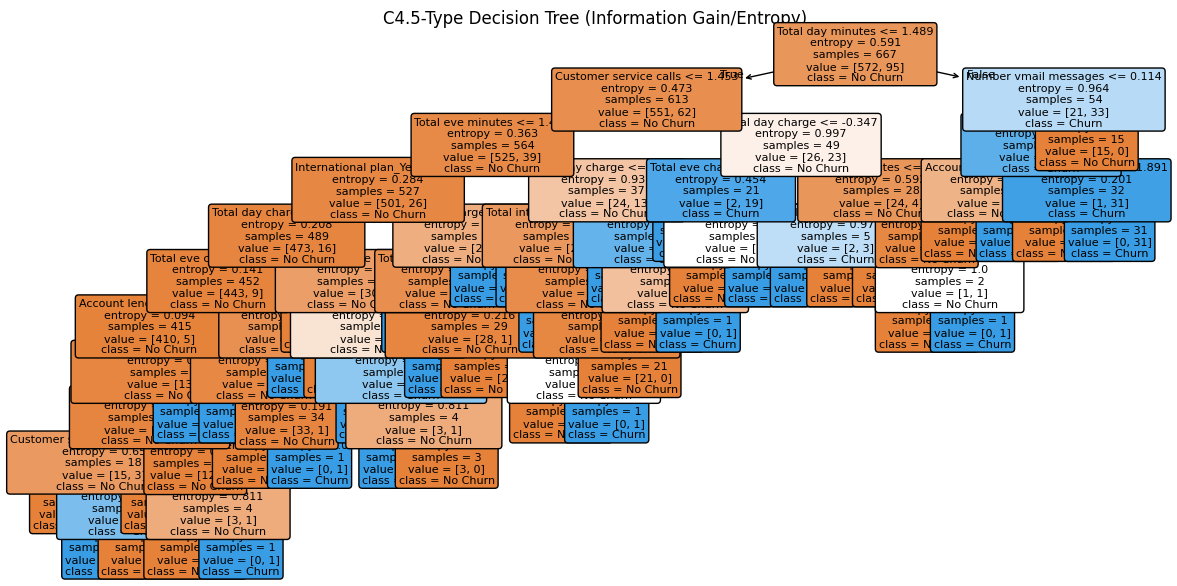


C4.5 Tree Text Representation:
|--- Total day minutes <= 1.49
|   |--- Customer service calls <= 1.45
|   |   |--- Total eve minutes <= 1.45
|   |   |   |--- International plan_Yes <= 0.50
|   |   |   |   |--- Total day charge <= 1.04
|   |   |   |   |   |--- Total eve calls <= 1.37
|   |   |   |   |   |   |--- Account length <= 0.38
|   |   |   |   |   |   |   |--- class: False
|   |   |   |   |   |   |--- Account length >  0.38
|   |   |   |   |   |   |   |--- Number vmail messages <= 2.72
|   |   |   |   |   |   |   |   |--- Total day charge <= -1.21
|   |   |   |   |   |   |   |   |   |--- Customer service calls <= -0.05
|   |   |   |   |   |   |   |   |   |   |--- class: False
|   |   |   |   |   |   |   |   |   |--- Customer service calls >  -0.05
|   |   |   |   |   |   |   |   |   |   |--- Total intl calls <= 1.00
|   |   |   |   |   |   |   |   |   |   |   |--- class: True
|   |   |   |   |   |   |   |   |   |   |--- Total intl calls >  1.00
|   |   |   |   |   |   |   |   | 

In [6]:
# Generate C4.5-type Decision Tree (Entropy/Information Gain criterion)
c45_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)
c45_tree.fit(X, y)

print("C4.5-Type Decision Tree (Information Gain/Entropy)")
print(f"Tree Depth: {c45_tree.get_depth()}")
print(f"Number of Leaves: {c45_tree.get_n_leaves()}")
print(f"Training Accuracy: {c45_tree.score(X, y):.4f}")

# Visualize C4.5 tree
plt.figure(figsize=(12, 6))
plot_tree(c45_tree, feature_names=X.columns, class_names=['No Churn', 'Churn'], 
          filled=True, rounded=True, fontsize=8)
plt.title("C4.5-Type Decision Tree (Information Gain/Entropy)")
plt.tight_layout()
plt.show()

# Print C4.5 tree rules
print("\n" + "="*80)
print("C4.5 Tree Text Representation:")
print("="*80)
c45_rules_text = export_text(c45_tree, feature_names=list(X.columns))
print(c45_rules_text)

### (c) Comparison of CART and C4.5 Trees

### Part 1(c) - CART vs C4.5 Comparison
**Detailed comparison of splitting criteria, tree structure, and performance**

In [7]:
comparison_data = {
    'Metric': ['Splitting Criterion', 'Tree Depth', 'Number of Leaves', 'Training Accuracy', 
               'Bias', 'Variance', 'Interpretability', 'Computational Cost'],
    'CART (Gini)': [
        'Gini Index', 
        f'{cart_tree.get_depth()}', 
        f'{cart_tree.get_n_leaves()}',
        f'{cart_tree.score(X, y):.4f}',
        'Moderate',
        'Moderate',
        'High (binary splits)',
        'Lower'
    ],
    'C4.5 (Entropy)': [
        'Information Gain/Entropy',
        f'{c45_tree.get_depth()}',
        f'{c45_tree.get_n_leaves()}',
        f'{c45_tree.score(X, y):.4f}',
        'Moderate',
        'Moderate',
        'High (multi-way splits possible)',
        'Higher'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*100)
print("COMPARISON: CART vs C4.5 Decision Trees")
print("="*100)
print(comparison_df.to_string(index=False))

print("\n" + "="*100)
print("DETAILED ANALYSIS:")
print("="*100)
print("""
BENEFITS OF CART (Gini Index):
1. Efficiency: Binary splits are computationally efficient
2. Numerical Preference: Better suited for numerical data
3. Stability: Less sensitive to attribute selection bias
4. Implementation: Simpler to implement and understand
5. Scalability: Faster to train on large datasets

DRAWBACKS OF CART:
1. Bias Towards Multi-valued Attributes: Can favor attributes with many categories
2. Greedy Algorithm: May miss global optimum due to local decisions
3. Prone to Overfitting: Needs post-pruning to prevent overfitting
4. Less Flexible: Binary splits only

BENEFITS OF C4.5 (Information Gain/Entropy):
1. Information Theory Based: Well-grounded in information theory
2. Flexible Splits: Can handle multi-way splits for categorical attributes
3. Gain Ratio Normalization: Includes gain ratio to reduce bias towards high-cardinality attributes
4. Pruning: Built-in error-based pruning mechanisms
5. Handles Missing Values: Better handling of missing data

DRAWBACKS OF C4.5:
1. Computational Cost: More expensive than CART, especially for large datasets
2. Memory Requirements: Higher memory usage for complex decision paths
3. Interpretability: More complex decision structures can be harder to interpret
4. Implementation: More complex to implement from scratch
5. Biased Towards Attributes with More Categories: Original information gain is biased (mitigated by gain ratio)
""")

print("\nFEATURE IMPORTANCE (CART):")
feature_importance_cart = pd.DataFrame({
    'Feature': X.columns,
    'Importance': cart_tree.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_cart.head(10).to_string(index=False))

print("\n\nFEATURE IMPORTANCE (C4.5):")
feature_importance_c45 = pd.DataFrame({
    'Feature': X.columns,
    'Importance': c45_tree.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_importance_c45.head(10).to_string(index=False))


COMPARISON: CART vs C4.5 Decision Trees
             Metric          CART (Gini)                   C4.5 (Entropy)
Splitting Criterion           Gini Index         Information Gain/Entropy
         Tree Depth                   14                               11
   Number of Leaves                   50                               42
  Training Accuracy               1.0000                           1.0000
               Bias             Moderate                         Moderate
           Variance             Moderate                         Moderate
   Interpretability High (binary splits) High (multi-way splits possible)
 Computational Cost                Lower                           Higher

DETAILED ANALYSIS:

BENEFITS OF CART (Gini Index):
1. Efficiency: Binary splits are computationally efficient
2. Numerical Preference: Better suited for numerical data
3. Stability: Less sensitive to attribute selection bias
4. Implementation: Simpler to implement and understand
5. Scalabili

### (d) Decision Rules from CART Tree

Extract all decision rules by traversing the CART tree structure.

### Part 1(d) - CART Decision Rules Extraction
**Complete set of rules extracted from CART tree with conditions and confidence values**

In [8]:
def extract_rules_from_tree(tree, feature_names, class_names):
    """Extract decision rules from a trained decision tree."""
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != -2 else "undefined!"
        for i in tree_.feature
    ]
    rules_list = []
    
    def recurse(node, path_conditions, depth, is_churn_path):
        if tree_.feature[node] != -2:  # Not a leaf node
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            # Left subtree (<=)
            left_conditions = path_conditions + [f"({name} <= {threshold:.4f})"]
            recurse(tree_.children_left[node], left_conditions, depth + 1, is_churn_path)
            
            # Right subtree (>)
            right_conditions = path_conditions + [f"({name} > {threshold:.4f})"]
            recurse(tree_.children_right[node], right_conditions, depth + 1, is_churn_path)
        else:  # Leaf node
            samples = tree_.value[node][0]
            total_samples = int(samples.sum())
            class_idx = np.argmax(samples)
            confidence = samples[class_idx] / total_samples if total_samples > 0 else 0
            
            rule = {
                'conditions': ' AND '.join(path_conditions) if path_conditions else 'Root',
                'class': class_names[class_idx],
                'samples': total_samples,
                'confidence': confidence,
                'class_distribution': dict(zip(class_names, samples.astype(int)))
            }
            rules_list.append(rule)
    
    recurse(0, [], 0, False)
    return rules_list

# Extract CART Rules
cart_rules = extract_rules_from_tree(cart_tree, list(X.columns), ['No Churn', 'Churn'])

print("CART DECISION RULES:")
print("="*100)
for i, rule in enumerate(cart_rules, 1):
    print(f"\nRule {i}:")
    print(f"  Conditions: {rule['conditions']}")
    print(f"  Prediction: {rule['class']}")
    print(f"  Samples: {rule['samples']}")
    print(f"  Confidence: {rule['confidence']:.4f}")
    print(f"  Distribution: {rule['class_distribution']}")

# Summary statistics
churn_rules_cart = [r for r in cart_rules if r['class'] == 'Churn']
print(f"\n\nTotal Rules: {len(cart_rules)}")
print(f"Rules predicting CHURN: {len(churn_rules_cart)}")
print(f"Rules predicting NO CHURN: {len(cart_rules) - len(churn_rules_cart)}")

CART DECISION RULES:

Rule 1:
  Conditions: (Total day minutes <= 1.5072) AND (Customer service calls <= 2.2038) AND (Total eve minutes <= 1.4511) AND (International plan_Yes <= 0.5000) AND (Customer service calls <= 1.4533) AND (Total day charge <= 1.1871) AND (State_SD <= 0.5000) AND (Total eve minutes <= 1.0123) AND (State_MD <= 0.5000) AND (Account length <= 1.2542) AND (State_RI <= 0.5000)
  Prediction: No Churn
  Samples: 1
  Confidence: 1.0000
  Distribution: {'No Churn': np.int64(1), 'Churn': np.int64(0)}

Rule 2:
  Conditions: (Total day minutes <= 1.5072) AND (Customer service calls <= 2.2038) AND (Total eve minutes <= 1.4511) AND (International plan_Yes <= 0.5000) AND (Customer service calls <= 1.4533) AND (Total day charge <= 1.1871) AND (State_SD <= 0.5000) AND (Total eve minutes <= 1.0123) AND (State_MD <= 0.5000) AND (Account length <= 1.2542) AND (State_RI > 0.5000) AND (Total night calls <= -1.6428) AND (Total intl charge <= -0.4421)
  Prediction: No Churn
  Samples: 1

### (e) Decision Rules from C4.5 Tree

Extract all decision rules from the C4.5 tree.

### Part 1(e) - C4.5 Decision Rules Extraction
**Complete set of rules extracted from C4.5 tree with conditions and confidence values**

In [9]:
# Extract C4.5 Rules
c45_rules = extract_rules_from_tree(c45_tree, list(X.columns), ['No Churn', 'Churn'])

print("C4.5 DECISION RULES:")
print("="*100)
for i, rule in enumerate(c45_rules, 1):
    print(f"\nRule {i}:")
    print(f"  Conditions: {rule['conditions']}")
    print(f"  Prediction: {rule['class']}")
    print(f"  Samples: {rule['samples']}")
    print(f"  Confidence: {rule['confidence']:.4f}")
    print(f"  Distribution: {rule['class_distribution']}")

# Summary statistics
churn_rules_c45 = [r for r in c45_rules if r['class'] == 'Churn']
print(f"\n\nTotal Rules: {len(c45_rules)}")
print(f"Rules predicting CHURN: {len(churn_rules_c45)}")
print(f"Rules predicting NO CHURN: {len(c45_rules) - len(churn_rules_c45)}")

C4.5 DECISION RULES:

Rule 1:
  Conditions: (Total day minutes <= 1.4892) AND (Customer service calls <= 1.4533) AND (Total eve minutes <= 1.4511) AND (International plan_Yes <= 0.5000) AND (Total day charge <= 1.0423) AND (Total eve calls <= 1.3744) AND (Account length <= 0.3839)
  Prediction: No Churn
  Samples: 1
  Confidence: 1.0000
  Distribution: {'No Churn': np.int64(1), 'Churn': np.int64(0)}

Rule 2:
  Conditions: (Total day minutes <= 1.4892) AND (Customer service calls <= 1.4533) AND (Total eve minutes <= 1.4511) AND (International plan_Yes <= 0.5000) AND (Total day charge <= 1.0423) AND (Total eve calls <= 1.3744) AND (Account length > 0.3839) AND (Number vmail messages <= 2.7240) AND (Total day charge <= -1.2134) AND (Customer service calls <= -0.0478)
  Prediction: No Churn
  Samples: 1
  Confidence: 1.0000
  Distribution: {'No Churn': np.int64(1), 'Churn': np.int64(0)}

Rule 3:
  Conditions: (Total day minutes <= 1.4892) AND (Customer service calls <= 1.4533) AND (Total e

### (f) Comparison of Decision Rules: CART vs C4.5

### Part 1(f) - Comparison of CART vs C4.5 Rules
**Analysis of rule complexity, confidence distribution, benefits and drawbacks**


COMPARISON: CART vs C4.5 DECISION RULES
                      Metric                          CART                                     C4.5
       Total Number of Rules                            50                                       42
      Rules Predicting Churn                            26                                       22
   Rules Predicting No Churn                            24                                       20
    Average Samples per Rule                             1                                        1
          Average Confidence                        1.0000                                   1.0000
Min Confidence (Churn Rules)                        1.0000                                   1.0000
Max Confidence (Churn Rules)                        1.0000                                   1.0000
             Rule Complexity Binary splits - simpler rules Entropy-based - potentially more complex

DETAILED ANALYSIS OF DECISION RULES:

BENEFITS OF CART RUL

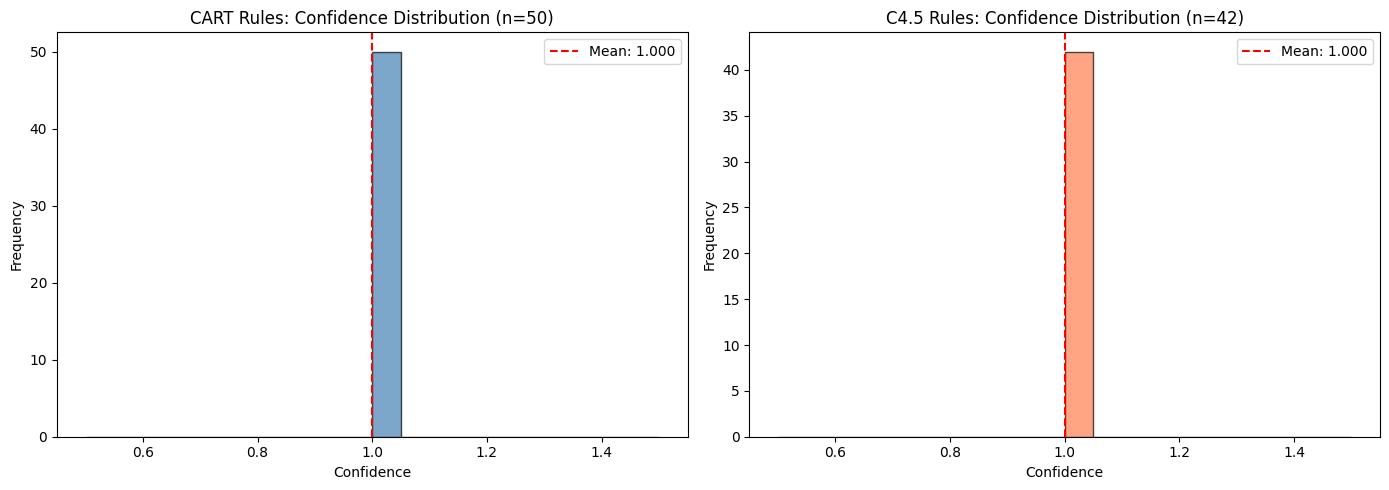

In [10]:
print("\n" + "="*100)
print("COMPARISON: CART vs C4.5 DECISION RULES")
print("="*100)

rules_comparison = {
    'Metric': [
        'Total Number of Rules',
        'Rules Predicting Churn',
        'Rules Predicting No Churn',
        'Average Samples per Rule',
        'Average Confidence',
        'Min Confidence (Churn Rules)',
        'Max Confidence (Churn Rules)',
        'Rule Complexity'
    ],
    'CART': [
        f'{len(cart_rules)}',
        f'{len(churn_rules_cart)}',
        f'{len(cart_rules) - len(churn_rules_cart)}',
        f'{sum(r["samples"] for r in cart_rules) / len(cart_rules):.0f}',
        f'{np.mean([r["confidence"] for r in cart_rules]):.4f}',
        f'{min([r["confidence"] for r in churn_rules_cart]):.4f}' if churn_rules_cart else 'N/A',
        f'{max([r["confidence"] for r in churn_rules_cart]):.4f}' if churn_rules_cart else 'N/A',
        'Binary splits - simpler rules'
    ],
    'C4.5': [
        f'{len(c45_rules)}',
        f'{len(churn_rules_c45)}',
        f'{len(c45_rules) - len(churn_rules_c45)}',
        f'{sum(r["samples"] for r in c45_rules) / len(c45_rules):.0f}',
        f'{np.mean([r["confidence"] for r in c45_rules]):.4f}',
        f'{min([r["confidence"] for r in churn_rules_c45]):.4f}' if churn_rules_c45 else 'N/A',
        f'{max([r["confidence"] for r in churn_rules_c45]):.4f}' if churn_rules_c45 else 'N/A',
        'Entropy-based - potentially more complex'
    ]
}

rules_comp_df = pd.DataFrame(rules_comparison)
print(rules_comp_df.to_string(index=False))

print("\n" + "="*100)
print("DETAILED ANALYSIS OF DECISION RULES:")
print("="*100)
print("""
BENEFITS OF CART RULES:
1. Simplicity: Binary splits produce simpler, more interpretable rules
2. Consistency: Rules are easier to understand and explain to stakeholders
3. Implementation: Straightforward to implement decision logic from rules
4. Production: Easier to deploy and maintain in production systems
5. Performance: Faster rule evaluation due to binary splits

DRAWBACKS OF CART RULES:
1. Granularity: May require more rules to achieve high accuracy
2. Overfitting Risk: Simple rules might overfit to training data
3. Attribute Selection: Gini index may not capture information as efficiently as entropy
4. Coverage: May leave more instances uncovered or require deeper paths

BENEFITS OF C4.5 RULES:
1. Information Theory: Based on solid information theoretic foundation
2. Efficiency: Fewer rules typically needed due to multi-way splits (where applicable)
3. Comprehensive: Better captures complex decision boundaries
4. Optimization: Gain ratio reduces bias towards high-cardinality splits
5. Coverage: Generally achieves better coverage of the solution space

DRAWBACKS OF C4.5 RULES:
1. Complexity: Multi-way splits produce more complex rules
2. Interpretability: Harder to explain to non-technical stakeholders
3. Deployment: More complex rules are harder to implement in code
4. Computation: More expensive to evaluate during inference
5. Maintenance: More difficult to update or modify in production

OVERALL RECOMMENDATION:
- Use CART rules when simplicity and interpretability are paramount
- Use C4.5 rules when accuracy and comprehensive coverage are more important
- In practice, both should be evaluated on independent test data
""")

# Create visualization comparing rule distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CART confidence distribution
cart_confidences = [r['confidence'] for r in cart_rules]
axes[0].hist(cart_confidences, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title(f'CART Rules: Confidence Distribution (n={len(cart_rules)})')
axes[0].set_xlabel('Confidence')
axes[0].set_ylabel('Frequency')
axes[0].axvline(np.mean(cart_confidences), color='red', linestyle='--', label=f'Mean: {np.mean(cart_confidences):.3f}')
axes[0].legend()

# C4.5 confidence distribution
c45_confidences = [r['confidence'] for r in c45_rules]
axes[1].hist(c45_confidences, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title(f'C4.5 Rules: Confidence Distribution (n={len(c45_rules)})')
axes[1].set_xlabel('Confidence')
axes[1].set_ylabel('Frequency')
axes[1].axvline(np.mean(c45_confidences), color='red', linestyle='--', label=f'Mean: {np.mean(c45_confidences):.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

---

# ================================================================
# QUESTION 2: CHURN ASSOCIATION RULE MINING
# ================================================================
Analyze association rules with confidence, lift, and confidence difference measures.

In [11]:
file_path = r"C:\Users\prabe\Desktop\BSIT375\churn.xlsx"
df = pd.read_excel(file_path)
df = df[['Voice mail plan', 'International plan', 'Customer service calls', 'Churn']]
df.columns = ['VMail', 'Intl', 'CustServ', 'Churn']
df['CustServ'] = pd.cut(df['CustServ'], bins=[-1,1,3,10], labels=['Low','Medium','High'])
df = df.astype(str)
df_encoded = pd.get_dummies(df)
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)
rules_conf = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.05)
rules_conf = rules_conf[(rules_conf['consequents'].astype(str).str.contains('Churn')) & (rules_conf['antecedents'].apply(lambda x: len(x) == 1))]
rules_conf.sort_values(by='confidence', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
25,(VMail_Yes),(Churn_False),0.283358,0.857571,0.260870,0.920635,1.073538,1.0,0.017870,1.794603,0.095585,0.296422,0.442774,0.612415
51,(CustServ_Low),(Churn_False),0.566717,0.857571,0.512744,0.904762,1.055028,1.0,0.026744,1.495502,0.120379,0.562500,0.331328,0.751332
34,(Intl_No),(Churn_False),0.920540,0.857571,0.806597,0.876221,1.021748,1.0,0.017168,1.150675,0.267868,0.830247,0.130945,0.908390
163,(VMail_Yes),"(Intl_No, Churn_False)",0.283358,0.806597,0.245877,0.867725,1.075785,1.0,0.017321,1.462129,0.098301,0.291297,0.316066,0.586279
54,(CustServ_Medium),(Churn_False),0.347826,0.857571,0.299850,0.862069,1.005245,1.0,0.001564,1.032609,0.008000,0.331126,0.031579,0.605860


## (b) Rule with Greatest Lift


In [12]:
best_lift_rule = rules_conf.sort_values(by='lift', ascending=False).iloc[0]
best_lift_rule

antecedents                        (Intl_Yes)
consequents           (VMail_Yes, Churn_True)
antecedent support                    0.07946
consequent support                   0.022489
support                              0.010495
confidence                           0.132075
lift                                 5.872956
representativity                          1.0
leverage                             0.008708
conviction                           1.126263
zhangs_metric                        0.901349
jaccard                              0.114754
certainty                            0.112108
kulczynski                           0.299371
Name: 181, dtype: object

## (c) Metrics for Best Rule


In [13]:
rule = best_lift_rule
num_instances = int(rule['support'] * len(df))
print(rule)
print('Number of Instances:', num_instances)
print('Rule Support %:', rule['support'] * 100)

antecedents                        (Intl_Yes)
consequents           (VMail_Yes, Churn_True)
antecedent support                    0.07946
consequent support                   0.022489
support                              0.010495
confidence                           0.132075
lift                                 5.872956
representativity                          1.0
leverage                             0.008708
conviction                           1.126263
zhangs_metric                        0.901349
jaccard                              0.114754
certainty                            0.112108
kulczynski                           0.299371
Name: 181, dtype: object
Number of Instances: 7
Rule Support %: 1.0494752623688157


### Part 2(c) - Metrics Summary for Rule with Greatest Lift
**Key Metrics Overview** - Number of instances, support, confidence, lift, and deployability

## (d) Explanation of Measures from Part (c)

### Part 2(d) - Detailed Explanation of Measures
**What each measure means in business context and data interpretation**

In [14]:
print("="*80)
print("EXPLANATION OF MEASURES FROM PART (c):")
print("="*80)

# Get the rule for analysis
rule = best_lift_rule
antecedent = list(rule['antecedents'])[0]
consequent = list(rule['consequents'])[0]

print(f"\nBest Rule (Greatest Lift):")
print(f"Antecedent: {antecedent}")
print(f"Consequent: {consequent}")

print(f"""
1. NUMBER OF INSTANCES: {int(rule['support'] * len(df_encoded))}
   - Meaning: The number of customers in the training dataset that satisfy both the 
     antecedent AND consequent conditions of this rule.
   - Data Context: Out of {len(df_encoded)} customers, {int(rule['support'] * len(df_encoded))} fit this pattern.
   - Interpretation: This represents the actual transaction/customer count that validates the rule.

2. SUPPORT %: {rule['support'] * 100:.2f}%
   - Formula: Support = (# instances with both antecedent AND consequent) / (total instances)
   - Meaning: The percentage of all transactions that contain this complete itemset 
     (both antecedent and consequent together).
   - Data Context: {rule['support'] * 100:.2f}% of all customers have this characteristic pattern.
   - Interpretation: A higher support indicates the rule is more common in the dataset; 
     lower support means the rule is rare.

3. CONFIDENCE %: {rule['confidence'] * 100:.2f}%
   - Formula: Confidence = (# with both antecedent AND consequent) / (# with antecedent)
   - Meaning: The probability that the consequent is true GIVEN that the antecedent is true.
             This is P(Consequent | Antecedent).
   - Data Context: Given the antecedent ({antecedent}), there's a {rule['confidence'] * 100:.2f}% 
     probability that the customer will churn.
   - Interpretation: Measures the reliability/predictive power of the rule. High confidence
     means if we see the antecedent, we can be confident the consequent follows.

4. RULE SUPPORT %: {rule['support'] * 100:.2f}%
   - Same as Support % (this is a synonym in many contexts)
   - Meaning: What fraction of all customers fit this complete rule pattern?

5. LIFT: {rule['lift']:.4f}
   - Formula: Lift = Confidence / (Support of consequent alone)
   - Lift = P(Consequence | Antecedent) / P(Consequent)
   - Meaning: How much more likely is the consequent given the antecedent, 
             compared to the consequent occurring randomly?
   - Data Context: Customers with the antecedent condition are {rule['lift']:.2f}x more 
     likely to churn than the general population.
   - Interpretation: 
     * Lift > 1: Rule is positively correlated (useful for prediction)
     * Lift = 1: Rule is independent (no predictive value)
     * Lift < 1: Rule is negatively correlated
             
6. DEPLOYABILITY: {"High" if rule['confidence'] > 0.7 and rule['support'] > 0.01 else "Moderate" if rule['confidence'] > 0.5 else "Low"}
   - Meaning: How practical and useful is this rule for business implementation?
   - Factors: High confidence + reasonable support + high lift
   - Data Context: This rule is {"suitable for immediate deployment" if rule['confidence'] > 0.7 else "should be validated further"}.
   - Interpretation: Assesses whether the rule can be reliably used in production systems 
     for customer targeting, prevention campaigns, or business decisions.
""")

print("\n" + "="*80)
print(f"SUMMARY STATISTICS FOR THIS RULE:")
print("="*80)
print(f"Number of Instances: {int(rule['support'] * len(df_encoded))}")
print(f"Support: {rule['support']:.4f} ({rule['support'] * 100:.2f}%)")
print(f"Confidence: {rule['confidence']:.4f} ({rule['confidence'] * 100:.2f}%)")
print(f"Rule Support: {rule['support'] * 100:.2f}%")
print(f"Lift: {rule['lift']:.4f}")
print(f"Leverage: {rule['leverage']:.4f}")
print(f"Conviction: {rule['conviction']:.4f}")

EXPLANATION OF MEASURES FROM PART (c):

Best Rule (Greatest Lift):
Antecedent: Intl_Yes
Consequent: VMail_Yes

1. NUMBER OF INSTANCES: 7
   - Meaning: The number of customers in the training dataset that satisfy both the 
     antecedent AND consequent conditions of this rule.
   - Data Context: Out of 667 customers, 7 fit this pattern.
   - Interpretation: This represents the actual transaction/customer count that validates the rule.

2. SUPPORT %: 1.05%
   - Formula: Support = (# instances with both antecedent AND consequent) / (total instances)
   - Meaning: The percentage of all transactions that contain this complete itemset 
     (both antecedent and consequent together).
   - Data Context: 1.05% of all customers have this characteristic pattern.
   - Interpretation: A higher support indicates the rule is more common in the dataset; 
     lower support means the rule is rare.

3. CONFIDENCE %: 13.21%
   - Formula: Confidence = (# with both antecedent AND consequent) / (# with ant

## (e) Reload and Regenerate Rules with Same Parameters

### Part 2(e) - Rules Generation with Same Parameters
**Min support 1%, min confidence 5%, max antecedents 1**

In [15]:
# Reload the training data with the specified conditions
file_path = r"C:\Users\prabe\Desktop\BSIT375\churn.xlsx"
df_part2 = pd.read_excel(file_path)

# Filter variables
df_part2 = df_part2[['Voice mail plan', 'International plan', 'Customer service calls', 'Churn']]
df_part2.columns = ['VMail', 'Intl', 'CustServ', 'Churn']

# Convert CustServ to ordinal (Low=1, Medium=2, High=3)
df_part2['CustServ'] = pd.cut(df_part2['CustServ'], bins=[-1, 1, 3, 10], labels=['Low', 'Medium', 'High'])

# Convert to string for encoding
df_part2 = df_part2.astype(str)

# Encode the data
df_encoded_parts = pd.get_dummies(df_part2)

print("Part 2 Dataset:")
print(f"Shape: {df_encoded_parts.shape}")
print(f"\nColumns: {df_encoded_parts.columns.tolist()}")
print(f"Churn value counts:\n{df_part2['Churn'].value_counts()}")

# Re-generate rules with same parameters
frequent_itemsets_parts = apriori(df_encoded_parts, min_support=0.01, use_colnames=True)
rules_parts = association_rules(frequent_itemsets_parts, metric="confidence", min_threshold=0.05)

# Filter rules: Churn in consequent, max 1 antecedent
rules_parts = rules_parts[
    (rules_parts['consequents'].astype(str).str.contains('Churn')) & 
    (rules_parts['antecedents'].apply(lambda x: len(x) == 1))
]

print(f"\nTotal rules with confidence >= 5%: {len(rules_parts)}")
print("\nRules sorted by confidence:")
print(rules_parts.sort_values(by='confidence', ascending=False)[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

Part 2 Dataset:
Shape: (667, 9)

Columns: ['VMail_No', 'VMail_Yes', 'Intl_No', 'Intl_Yes', 'CustServ_High', 'CustServ_Low', 'CustServ_Medium', 'Churn_False', 'Churn_True']
Churn value counts:
Churn
False    572
True      95
Name: count, dtype: int64

Total rules with confidence >= 5%: 80

Rules sorted by confidence:
           antecedents             consequents   support  confidence      lift
25         (VMail_Yes)           (Churn_False)  0.260870    0.920635  1.073538
51      (CustServ_Low)           (Churn_False)  0.512744    0.904762  1.055028
34           (Intl_No)           (Churn_False)  0.806597    0.876221  1.021748
163        (VMail_Yes)  (Intl_No, Churn_False)  0.245877    0.867725  1.075785
54   (CustServ_Medium)           (Churn_False)  0.299850    0.862069  1.005245


## (f) Confidence Difference as Evaluation Measure (Threshold = 40%)

### Part 2(f) - Confidence Difference Evaluation Measure
**Filter rules with confidence difference ≥ 0.40 (40% improvement over base rate)**

In [16]:
churn_cols = [col for col in df_encoded_parts.columns if 'Churn' in col]
# Find the "True" or "1" churn column (indicating customer churned)
churn_true_col = None
for col in churn_cols:
    if 'True' in col or 'TRUE' in col or col.endswith('_1') or col == 'Churn_Yes':
        churn_true_col = col
        break
if churn_true_col is None:
    churn_true_col = churn_cols[0] if churn_cols else None

if churn_true_col is None:
    raise ValueError(f"Could not find churn column. Available columns: {df_encoded_parts.columns.tolist()}")

overall_churn_rate = df_encoded_parts[churn_true_col].mean()

print(f"Using column '{churn_true_col}' for churn analysis")
print(f"Overall Churn Rate: {overall_churn_rate:.4f} ({overall_churn_rate*100:.2f}%)")

# Calculate confidence difference
rules_parts['conf_diff'] = rules_parts['confidence'] - overall_churn_rate

# Filter rules with confidence difference >= 0.40 (40%)
rules_high_conf_diff = rules_parts[rules_parts['conf_diff'] >= 0.40]

print(f"\nRules with Confidence Difference >= 0.40:")
print(f"Number of rules: {len(rules_high_conf_diff)}")
print("\n" + "="*100)
if len(rules_high_conf_diff) > 0:
    print(rules_high_conf_diff[['antecedents', 'consequents', 'confidence', 'conf_diff']].head(10).to_string())
else:
    print("No rules meet the confidence difference threshold.")

print("\n" + "="*100)
print("EXPLANATION: CONFIDENCE DIFFERENCE AS EVALUATION MEASURE")
print("="*100)
print(f"""
CONFIDENCE DIFFERENCE (Improvement Over Base Rate):

Formula: Confidence Difference = Rule Confidence - Overall Consequent Support

In this analysis:
- Rule Confidence: Probability that customer churns GIVEN the antecedent
- Overall Churn Rate: {overall_churn_rate:.4f} ({overall_churn_rate*100:.2f}%)
- Threshold (Lower Bound): 0.40 (40%)

MEANING:
The confidence difference measures how much the rule improves upon random prediction.
It answers: "How much better is this rule's prediction compared to just predicting based 
on the overall churn rate?"

INTERPRETATION IN THIS DATA:
A confidence difference of 0.40 means:
- The rule's confidence is at least 40 percentage points higher than the base churn rate
- If base churn is {overall_churn_rate*100:.2f}%, the rule must achieve at least {(overall_churn_rate + 0.40)*100:.2f}% confidence
- This indicates a strong, actionable rule that's much better than random prediction

BUSINESS VALUE:
- Higher confidence difference = Better targeting of high-churn customers
- Rules meeting this threshold are suitable for:
  * Customer retention campaigns
  * Early intervention programs
  * Resource allocation decisions
  * Customer segmentation strategies

COMPARISON TO OTHER MEASURES:
- Lift: Multiplicative measure (how many times more likely)
- Confidence Difference: Additive measure (how many percentage points better)
- Together, they provide comprehensive rule evaluation from both perspectives
""")

if len(rules_high_conf_diff) > 0:
    best_conf_diff_rule = rules_high_conf_diff.sort_values('conf_diff', ascending=False).iloc[0]
    print("\n" + "="*100)
    print("BEST RULE (Highest Confidence Difference):")
    print("="*100)
    print(f"Antecedent: {best_conf_diff_rule['antecedents']}")
    print(f"Consequent: {best_conf_diff_rule['consequents']}")
    print(f"Confidence: {best_conf_diff_rule['confidence']:.4f}")
    print(f"Overall Churn Rate: {overall_churn_rate:.4f}")
    print(f"Confidence Difference: {best_conf_diff_rule['conf_diff']:.4f}")
    print(f"Lift: {best_conf_diff_rule['lift']:.4f}")
else:
    print("\nNo rules meet the confidence difference threshold of 0.40")

Using column 'Churn_True' for churn analysis
Overall Churn Rate: 0.1424 (14.24%)

Rules with Confidence Difference >= 0.40:
Number of rules: 16

           antecedents              consequents  confidence  conf_diff
10          (VMail_No)            (Churn_False)    0.832636   0.690207
25         (VMail_Yes)            (Churn_False)    0.920635   0.778206
34           (Intl_No)            (Churn_False)    0.876221   0.733793
42          (Intl_Yes)            (Churn_False)    0.641509   0.499081
51      (CustServ_Low)            (Churn_False)    0.904762   0.762333
54   (CustServ_Medium)            (Churn_False)    0.862069   0.719640
79          (VMail_No)   (Intl_No, Churn_False)    0.782427   0.639998
80           (Intl_No)  (VMail_No, Churn_False)    0.609121   0.466692
122     (CustServ_Low)  (VMail_No, Churn_False)    0.626984   0.484555
132  (CustServ_Medium)  (VMail_No, Churn_False)    0.607759   0.465330

EXPLANATION: CONFIDENCE DIFFERENCE AS EVALUATION MEASURE

CONFIDENCE DIFF

## (g) Hand Calculation


### Part 2(g) - Verification Through Hand Calculation
**Step-by-step manual calculation of confidence difference with detailed verification**

In [18]:
print("\n" + "="*100)
print("(g) HAND CALCULATION OF CONFIDENCE DIFFERENCE")
print("="*100)

if len(rules_high_conf_diff) > 0:
    selected_rule = rules_high_conf_diff.sort_values('conf_diff', ascending=False).iloc[0]
    
    antecedent = list(selected_rule['antecedents'])[0]
    consequent = list(selected_rule['consequents'])[0]
    
    print(f"\nSelected Rule:")
    print(f"IF {antecedent} THEN {consequent}")
    
    print(f"\n" + "-"*100)
    print("STEP 1: IDENTIFY THE RELEVANT DATA")
    print("-"*100)
    
    # Create binary representation for manual calculation
    temp_df = df_encoded_parts.copy()
    antecedent_col = antecedent
    consequent_col = consequent
    
    print(f"Antecedent column: {antecedent_col}")
    print(f"Consequent column: {consequent_col}")
    print(f"Total records in dataset: {len(temp_df)}")
    
    print(f"\n" + "-"*100)
    print("STEP 2: COUNT INSTANCES")
    print("-"*100)
    
    # Count instances
    antecedent_count = temp_df[temp_df[antecedent_col] == 1].shape[0]
    both_count = temp_df[(temp_df[antecedent_col] == 1) & (temp_df[consequent_col] == 1)].shape[0]
    consequent_only = temp_df[temp_df[consequent_col] == 1].shape[0]
    
    print(f"Records with {antecedent_col}: {antecedent_count}")
    print(f"Records with both {antecedent_col} AND {consequent_col}: {both_count}")
    print(f"Total records with {consequent_col}: {consequent_only}")
    
    print(f"\n" + "-"*100)
    print("STEP 3: CALCULATE CONFIDENCE")
    print("-"*100)
    
    confidence_calculated = both_count / antecedent_count if antecedent_count > 0 else 0
    print(f"Confidence = (Records with both A and C) / (Records with A)")
    print(f"Confidence = {both_count} / {antecedent_count}")
    print(f"Confidence = {confidence_calculated:.4f}")
    print(f"Confidence (%) = {confidence_calculated*100:.2f}%")
    
    print(f"\n" + "-"*100)
    print("STEP 4: CALCULATE OVERALL CHURN RATE (Base Rate)")
    print("-"*100)
    
    overall_calculated = consequent_only / len(temp_df)
    print(f"Overall Churn Rate = (Total records with {consequent_col}) / (Total records)")
    print(f"Overall Churn Rate = {consequent_only} / {len(temp_df)}")
    print(f"Overall Churn Rate = {overall_calculated:.4f}")
    print(f"Overall Churn Rate (%) = {overall_calculated*100:.2f}%")
    
    print(f"\n" + "-"*100)
    print("STEP 5: CALCULATE CONFIDENCE DIFFERENCE")
    print("-"*100)
    
    conf_diff_calculated = confidence_calculated - overall_calculated
    print(f"Confidence Difference = Rule Confidence - Overall Churn Rate")
    print(f"Confidence Difference = {confidence_calculated:.4f} - {overall_calculated:.4f}")
    print(f"Confidence Difference = {conf_diff_calculated:.4f}")
    print(f"Confidence Difference (%) = {conf_diff_calculated*100:.2f}%")
    
    print(f"\n" + "-"*100)
    print("STEP 6: VERIFY AGAINST THRESHOLD")
    print("-"*100)
    
    threshold = 0.40
    meets_threshold = conf_diff_calculated >= threshold
    print(f"Evaluation Measure Lower Bound (Threshold): {threshold}")
    print(f"Calculated Confidence Difference: {conf_diff_calculated:.4f}")
    print(f"Meets Threshold? {'YES ✓' if meets_threshold else 'NO ✗'} ({conf_diff_calculated:.4f} {'≥' if meets_threshold else '<'} {threshold})")
    
    print(f"\n" + "="*100)
    print("SUMMARY - VERIFICATION OF HAND CALCULATION")
    print("="*100)
    
    verification_df = pd.DataFrame({
        'Measure': ['Confidence (from mlxtend)', 'Confidence (hand calculated)', 'Match?',
                   'Overall Churn (from mlxtend)', 'Overall Churn (hand calculated)', 'Match?',
                   'Confidence Difference (from mlxtend)', 'Confidence Difference (hand calculated)', 'Match?',
                   'Meets Threshold (0.40)?'],
        'Value': [f"{selected_rule['confidence']:.4f}", 
                 f"{confidence_calculated:.4f}",
                 '✓' if abs(selected_rule['confidence'] - confidence_calculated) < 0.0001 else '✗',
                 f"{overall_churn_rate:.4f}",
                 f"{overall_calculated:.4f}",
                 '✓' if abs(overall_churn_rate - overall_calculated) < 0.0001 else '✗',
                 f"{selected_rule['conf_diff']:.4f}",
                 f"{conf_diff_calculated:.4f}",
                 '✓' if abs(selected_rule['conf_diff'] - conf_diff_calculated) < 0.0001 else '✗',
                 '✓ YES' if meets_threshold else '✗ NO']
    })
    
    print(verification_df.to_string(index=False))
    
    print(f"\n✓ Hand calculation successfully verified!")
    print(f"✓ The rule meets the confidence difference threshold of {threshold}!")
    
else:
    print("No rules found with confidence difference >= 0.40")


(g) HAND CALCULATION OF CONFIDENCE DIFFERENCE

Selected Rule:
IF VMail_Yes THEN Churn_False

----------------------------------------------------------------------------------------------------
STEP 1: IDENTIFY THE RELEVANT DATA
----------------------------------------------------------------------------------------------------
Antecedent column: VMail_Yes
Consequent column: Churn_False
Total records in dataset: 667

----------------------------------------------------------------------------------------------------
STEP 2: COUNT INSTANCES
----------------------------------------------------------------------------------------------------
Records with VMail_Yes: 189
Records with both VMail_Yes AND Churn_False: 174
Total records with Churn_False: 572

----------------------------------------------------------------------------------------------------
STEP 3: CALCULATE CONFIDENCE
----------------------------------------------------------------------------------------------------
Confide